# 3. Audio Similarity Using Pretrained Embeddings 

Measure the similarity between different audio clips using embeddings extracted from a pretrained audio model. 

## Suggested Datasets 

• speech_commands  |  TensorFlow Datasets 

## Tasks 

- Load multiple audio clips from the selected dataset. 

- Extract embeddings using a pretrained audio model such as YAMNet, OpenL3, CLAP or Wav2Vec2. 

- Compute pairwise similarity and distance scores. 

- Visualize the relationships using a similarity heatmap and distance matrix. 

## Deliverables 

A properly executed Jupyter Notebook (.ipynb). 

Similarity heatmap and distance matrix. 

## Notebook Requirements 

Use separate sections for dataset loading, preprocessing, model inference, visualization and observations. 

Execute all notebook cells before submission. 

Ensure all figures, printed outputs and results are visible in the submitted notebook. 

Include the required dataset links and model references inside the notebook. 

Use clear comments and concise explanations for each major step. 

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances

C:\Users\gouth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

In [3]:
audio_files = [
    "dataset/cat_1.wav",
    "dataset/cat_2.wav",
    "dataset/dog.wav",
    "dataset/on.wav"
]

In [4]:
embeddings = []
labels = []

for file in audio_files:

    audio, sr = librosa.load(file, sr=16000)

    scores, embedding, spectrogram = yamnet(audio)

    embedding = np.mean(embedding.numpy(), axis=0)

    embeddings.append(embedding)

    labels.append(file.split("/")[-1])

In [5]:
embeddings = np.array(embeddings)

print(embeddings.shape)

(4, 1024)


In [6]:
similarity = cosine_similarity(embeddings)

print(similarity)

[[0.9999999  0.6352728  0.6797221  0.6672385 ]
 [0.6352728  1.0000001  0.67429435 0.84097284]
 [0.6797221  0.67429435 0.99999976 0.7225535 ]
 [0.6672385  0.84097284 0.7225535  0.99999976]]


In [7]:
distance = pairwise_distances(
    embeddings,
    metric="euclidean"
)

print(distance)

[[0.        4.7804623 4.605563  4.628524 ]
 [4.7804623 0.        3.8830943 2.5972674]
 [4.605563  3.8830943 0.        3.674432 ]
 [4.628524  2.5972674 3.674432  0.       ]]


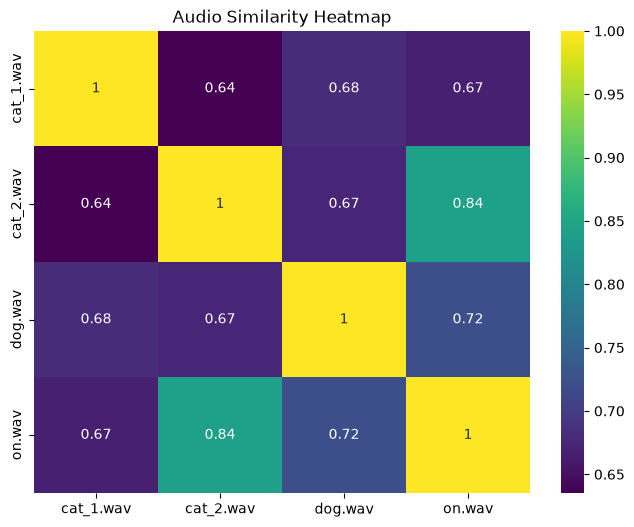

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    similarity,
    annot=True,
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Audio Similarity Heatmap")
plt.show()

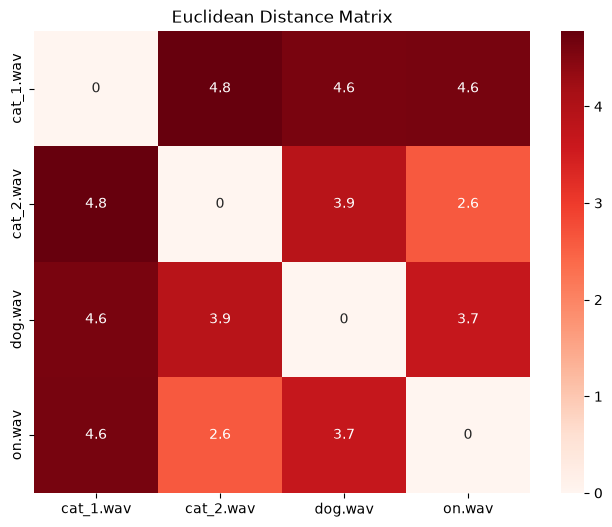

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    distance,
    annot=True,
    cmap="Reds",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Euclidean Distance Matrix")
plt.show()